In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn import tree
from sklearn.preprocessing import LabelEncoder


In [4]:
df = pd.read_csv("archive (4).zip")
df.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


In [11]:
df.shape

(10000, 7)

In [6]:
df.describe()

,size (cm),weight (g),avg_price (₹)
count,10000.000000,10000.000000,10000.000000
mean,8.430600,455.457720,77.016720
std,6.396915,731.643087,38.946916
min,0.900000,4.500000,9.000000
25%,3.700000,45.800000,45.575000
50%,7.200000,168.800000,75.400000
75%,10.100000,365.275000,100.700000
max,27.500000,3299.800000,165.000000


In [7]:
df.isnull().sum()

size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64

In [12]:
cat_cols = ["color", "taste", "shape"]
for i in cat_cols:
    print(df[i].value_counts())

green     2029
red       1943
brown     1541
yellow    1002
pink       998
orange     996
purple     988
blue       503
Name: color, dtype: int64
sweet    7504
tangy    2015
sour      481
Name: taste, dtype: int64
round    5016
oval     4482
long      502
Name: shape, dtype: int64


In [14]:
encoded_df = pd.get_dummies(df, columns = ["color", "taste", "shape"])
encoded_df.head()

,size (cm),weight (g),avg_price (₹),fruit_name,color_blue,color_brown,color_green,color_orange,color_pink,color_purple,color_red,color_yellow,taste_sour,taste_sweet,taste_tangy,shape_long,shape_oval,shape_round
0,25.4,3089.2,137.1,watermelon,0,0,1,0,0,0,0,0,0,1,0,0,0,1
1,24.6,3283.9,163.8,watermelon,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,7.8,319.0,91.3,custard apple,0,0,1,0,0,0,0,0,0,1,0,0,0,1
3,20.0,1607.0,85.7,papaya,0,0,0,1,0,0,0,0,0,1,0,0,1,0
4,10.2,131.5,37.8,banana,0,0,0,0,0,0,0,1,0,1,0,1,0,0


In [15]:
X = encoded_df.drop(columns ="fruit_name", axis=1)
Y = encoded_df["fruit_name"]

In [20]:
X_train, X_test , Y_train , Y_test = train_test_split(X,Y , test_size = 0.2, random_state =42)
rf= RandomForestClassifier(
    n_estimators= 50,
    max_depth = 4,
    oob_score=True,
    max_features=10
)

rf.fit(X_train, Y_train)

RandomForestClassifier(max_depth=4, max_features=10, n_estimators=50,
                       oob_score=True)

In [21]:
pred_y = rf.predict(X_test)
print("Accuracy: ", accuracy_score(Y_test, pred_y))

Accuracy:  0.9635


In [ ]:
#X_train, X_test , Y_train , Y_test = train_test_split(X,Y , test_size = 0.2, random_state =42)
#rf= RandomForestClassifier(
 #   max_depth = 4,
 #   oob_score=True,
 #   max_features=10
#)

#rf.fit(X_train, Y_train)

RandomForestClassifier(max_depth=4, max_features=10, oob_score=True)

In [ ]:
#pred_y = rf.predict(X_test)
#print("Accuracy: ", accuracy_score(Y_test, pred_y))

Accuracy:  0.9635


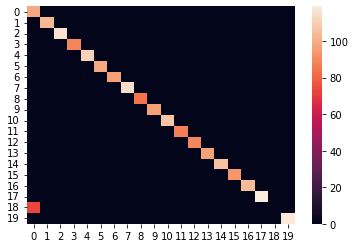

In [29]:
import seaborn as sns
cm = confusion_matrix(Y_test, pred_y)
sns.heatmap(cm)
plt.show()

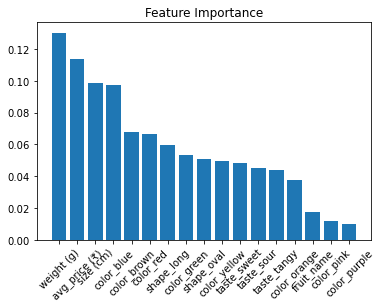

In [32]:
imp = rf.feature_importances_
index = np.argsort(imp)[::-1]

plt.figure
plt.title("Feature Importance")
plt.bar(range(len(imp)), imp[index])
plt.xticks(range(len(imp)), [encoded_df.columns[i] for i in index], rotation= 45)
plt.show()